# 🛒 SmartCart Customer Segmentation using Machine Learning

**Unsupervised Learning • Customer Analytics • Business Intelligence**

---

## 📖 Project Overview

Customer segmentation is one of the most valuable applications of Machine Learning in retail and e-commerce. Since every customer has unique purchasing habits, shopping frequency, income level, and product preferences, treating all customers the same often leads to ineffective marketing strategies.

The objective of this project is to segment **SmartCart customers** into meaningful groups using **Unsupervised Machine Learning (Clustering)**.

The project follows a complete ML pipeline:

1. **Data Preprocessing** — handling missing values, dropping unnecessary columns
2. **Feature Engineering** — creating `Age`, `Customer_Tenure_Days`, `Total_Spending`, `Total_Children`, simplifying `Education` and `Living_With`
3. **Exploratory Data Analysis** — pair plots and correlation heatmaps
4. **Outlier Removal** — dropping extreme observations
5. **Encoding & Scaling** — One-Hot Encoding + `StandardScaler`
6. **Dimensionality Reduction** — PCA
7. **Optimal K Selection** — Elbow Method + Silhouette Score → **K = 4**
8. **Clustering** — K-Means vs. Agglomerative Hierarchical Clustering
9. **Cluster Analysis** — profiling each segment

Based on the visualization results, **Agglomerative Clustering** produces more compact and well-separated customer groups, making it the preferred algorithm for this project.

---

## 🎯 Project Objectives

| # | Objective |
|---|-----------|
| 🧹 | Clean and preprocess customer data |
| ⚙️ | Create meaningful customer features |
| 📊 | Explore customer purchasing behavior |
| 🚫 | Detect and remove outliers |
| 🔄 | Encode categorical variables |
| 📏 | Scale numerical features |
| 📉 | Reduce dimensions using PCA |
| 🎯 | Determine the optimal number of clusters |
| 🤖 | Apply K-Means Clustering |
| 🌳 | Apply Agglomerative Clustering |
| 📈 | Compare clustering performance |
| 💡 | Generate business insights |

---

## 🔄 Machine Learning Workflow

📂 Load Dataset → 🧹 Cleaning → ⚙️ Feature Engineering → 📊 EDA → 🚫 Outlier Removal → 🔄 One-Hot Encoding → 📏 Scaling → 📉 PCA → 🎯 Find Best K → 🤖 K-Means / 🌳 Agglomerative → 📈 Cluster Analysis → 💡 Insights

---

## 🧹 Data Preprocessing

**1. Handle Missing Values** — Missing `Income` values imputed with the median.

**2. Feature Engineering** — New, business-meaningful features:

| New Feature | Formula |
|---|---|
| `Age` | `2026 - Year_Birth` |
| `Customer_Tenure_Days` | `max(Dt_Customer) - Dt_Customer` |
| `Total_Spending` | Sum of all `Mnt*` spending columns |
| `Total_Children` | `Kidhome + Teenhome` |
| `Education` | Simplified to Undergraduate / Graduate / PostGraduate |
| `Living_With` | Simplified to Alone / Partner |

**3. Drop Redundant Columns** — `ID`, `Year_Birth`, `Marital_Status`, `Kidhome`, `Teenhome`, `Dt_Customer`, and individual `Mnt*` columns dropped once replacements exist.

---

## 📊 Exploratory Data Analysis & Outlier Detection

A pair plot across `Income`, `Recency`, `Response`, `Age`, `Total_Spending`, and `Total_Children` reveals extreme income and age outliers.

> ✅ **Result:** Data size reduced from **2,240 → 2,236** records after removing age (>90) and income (>600,000) outliers.

A correlation heatmap is used to check relationships between numerical features before modeling.

---

## 🔄 Feature Encoding & Scaling

Categorical columns (`Education`, `Living_With`) are transformed with `OneHotEncoder`, then all numerical features are standardized with `StandardScaler` so no single feature dominates distance-based clustering.

---

## 📉 Dimensionality Reduction — PCA

Both 2D and 3D PCA projections are generated to visualize the customer feature space.

> Explained variance ratio (3 components): **≈ [0.232, 0.114, 0.104]** — roughly **45%** of total variance captured.

---

## 🎯 Finding the Optimal Number of Clusters

| Method | Result |
|---|---|
| 📉 Elbow Method (`KneeLocator`) | **Best K = 4** |
| 📈 Silhouette Score | Peaks around **K = 4–5**, confirming the elbow result |

---

## 🤖🌳 Clustering — K-Means vs. Agglomerative

Both algorithms are fit with **K = 4** and visualized in 3D PCA space.

| Algorithm | Observation |
|---|---|
| 🤖 K-Means | Reasonable separation, but cluster boundaries overlap more |
| 🌳 Agglomerative (Ward linkage) | Tighter, more compact, better-separated clusters |

> ✅ **Decision:** Agglomerative Clustering is selected for further analysis based on visual cluster compactness and separation.

---

## 📈 Characterization of Clustering

Cluster labels are attached back to the feature set, then profiled using count plots, scatter plots (Income vs. Total Spending), and a `groupby("clusters").mean()` summary table.

### 💡 Cluster Insights

| Cluster | Profile |
|---|---|
| 🔴 0 | Lower income, lower spending — price-sensitive shoppers |
| 🔵 1 | Higher income, higher spending — premium/loyal customers |
| 🟡 2 | Lower-to-mid income, low spending — occasional/deal-driven shoppers |
| 🟢 3 | Mid-to-high income, moderate-to-high spending — steady, engaged customers |

---

## 📌 Conclusion

This project demonstrates an end-to-end ML pipeline for customer segmentation. SmartCart customers are grouped into **four meaningful segments** using data preprocessing, feature engineering, PCA, and clustering. **Agglomerative Clustering** produced better-defined groups than K-Means, making it the preferred model.

These segments help the business:
- 🎯 Deliver Personalized Marketing
- 💰 Increase Revenue
- ❤️ Improve Customer Retention
- 📦 Offer Better Product Recommendations
- 📈 Support Data-Driven Decision Making

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from kneed import KneeLocator
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering

In [2]:
df = pd.read_csv("smartcart_customers.csv")

In [3]:
df.head()
df.shape
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

## Data PreProcessing

### 1. Handle Missing Values

In [4]:
df["Income"] = df["Income"].fillna(df["Income"].median())

In [5]:
df.isnull().sum()
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


### 2. Feature Engineering

In [6]:
 #Age
df["Age"] = 2026 - df["Year_Birth"]

In [7]:
# Customer Joining Date
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst = True)
reference_date = df["Dt_Customer"].max()

df["Customer_Tenure_Days"] = (reference_date - df["Dt_Customer"]).dt.days

In [8]:
#Spending
df["Total_Spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

In [9]:
#Total Children
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

In [10]:
df["Education"].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [11]:
# Education
df["Education"]= df["Education"].replace({
    "Basic":"Undergraduate", "2n Cycle":"Undergraduate",
    "Graduation": "Graduate",
    "Master":"PostGraduate", "PhD" : "PostGraduate"
})

In [12]:
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [13]:
df["Living_With"]= df["Marital_Status"].replace({
    "Married":"Partner", "Together":"Partner",
    "Single": "Alone", "Divorced": "Alone", "Widow": "Alone", 
    "Absurd": "Alone" , "YOLO": "Alone"
})

In [14]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,663,1617,0,Alone
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,113,27,2,Alone
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,312,776,0,Partner
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,139,53,1,Partner
4,5324,1981,PostGraduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,161,422,1,Partner


## Drop Columns

In [15]:
col = ["ID","Year_Birth", "Marital_Status","Kidhome","Teenhome", "Dt_Customer"]
spending_cols = ["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]

col_to_drop = col + spending_cols

df_cleaned = df.drop(columns = col_to_drop)

In [16]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,PostGraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


## Outliers 

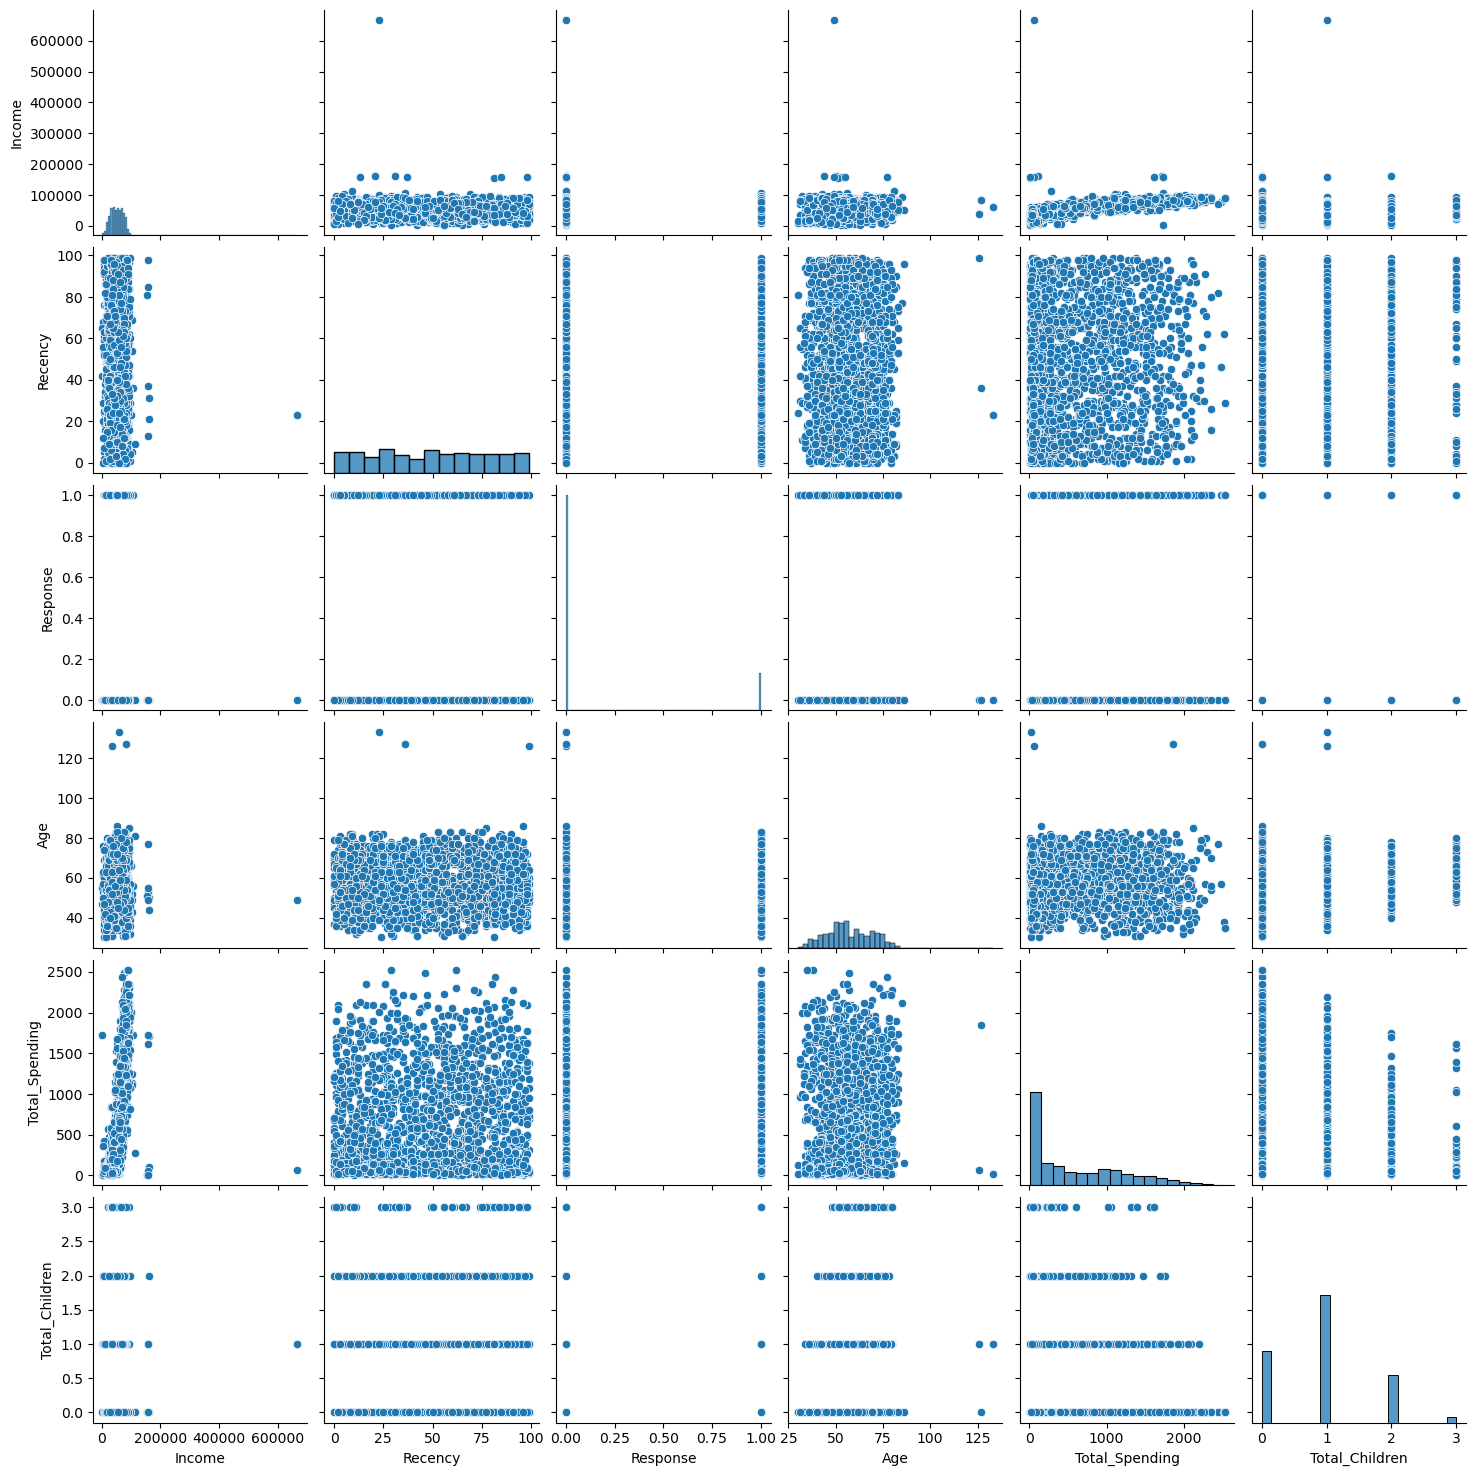

In [17]:
cols = ["Income", "Recency", "Response", "Age", "Total_Spending", "Total_Children"]
sns.pairplot(df_cleaned[cols])

### Remove outlier

In [18]:
print("Data Size with outliers:", len(df_cleaned))

df_cleaned = df_cleaned[(df_cleaned["Age"]<90)]
df_cleaned = df_cleaned[(df_cleaned["Income"]<600_000)]

print("Data Size without outliers:", len(df_cleaned))

Data Size with outliers: 2240
Data Size without outliers: 2236


## HeatMap

In [19]:
corr = df_cleaned.corr(numeric_only=True) #Uses only numeric columns

<Axes: >

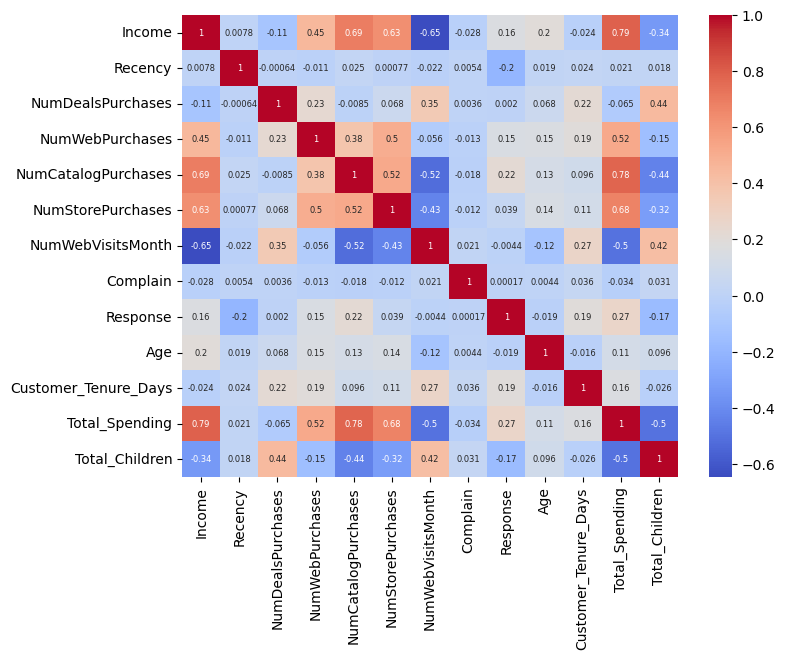

In [20]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size":6},
    cmap="coolwarm"
    
)

## Feature Encoding

In [21]:
ohe = OneHotEncoder()

cat_cols = ["Education", "Living_With"]

encoded_cols = ohe.fit_transform(df_cleaned[cat_cols])

In [22]:
encoded_df = pd.DataFrame(encoded_cols.toarray(), columns=ohe.get_feature_names_out(cat_cols), index=df_cleaned.index)

In [23]:
df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols),encoded_df],axis=1)

In [24]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_PostGraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


## Scaling Data

In [25]:
X = df_encoded

In [26]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Visualize

In [27]:
## 2D
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

Text(0.5, 1.0, '2d Projection')

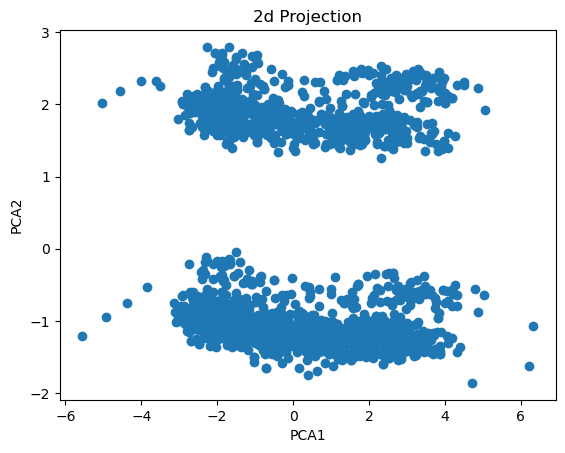

In [28]:
#plot 2D
plt.scatter(X_pca[:, 0], X_pca[:, 1])

plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.title("2d Projection")

In [29]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454])

In [30]:
# 3d format
pca = PCA(n_components=3)

X_pca = pca.fit_transform(X_scaled)

In [31]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

Text(0.5, 0.92, '3d Projection')

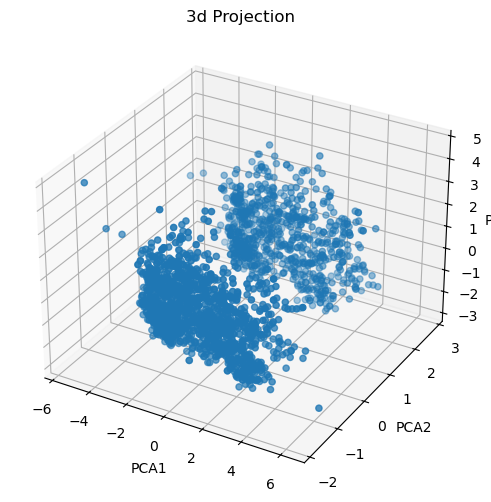

In [32]:
# plot 3d
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2])

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d Projection")

## Analyze K value

### 1. Elbow Method

In [33]:
wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k,random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [34]:
knee = KneeLocator(range(1,11), wcss, curve="convex", direction="decreasing")
optimal_k = knee.elbow

In [35]:
print("Best K = ", optimal_k)

Best K =  4


Text(0, 0.5, 'WCSS')

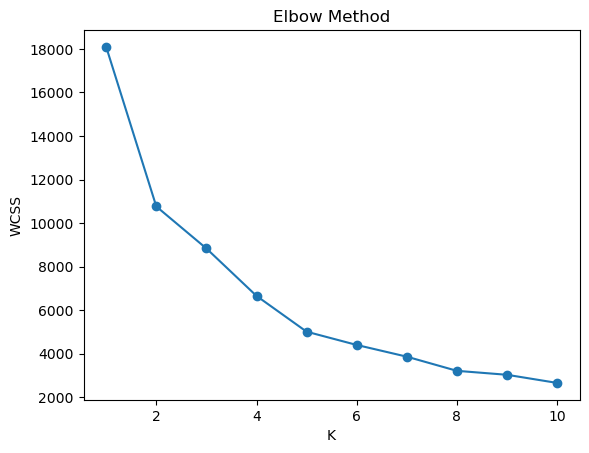

In [36]:
#plot
plt.plot(range(1,11),wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("WCSS")

### 2. Silhoutte score

In [37]:
scores = []
for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca , labels)
    scores.append(score)

Text(0, 0.5, 'Silhoutte Score')

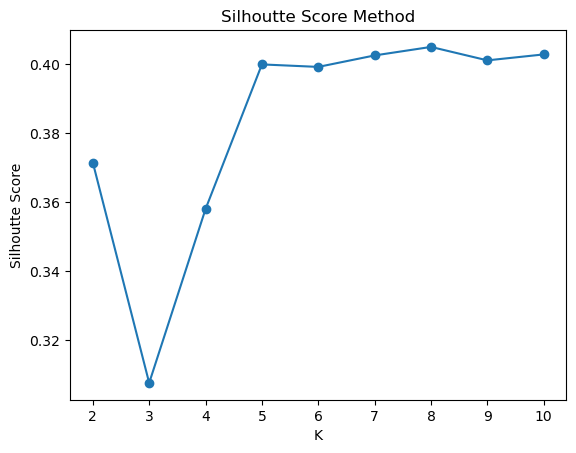

In [38]:
# plot
#plot
plt.plot(range(2,11),scores, marker='o')

plt.title("Silhoutte Score Method")
plt.xlabel("K")
plt.ylabel("Silhoutte Score")

#### Combined Plot

Text(0, 0.5, 'Silhoutte Score')

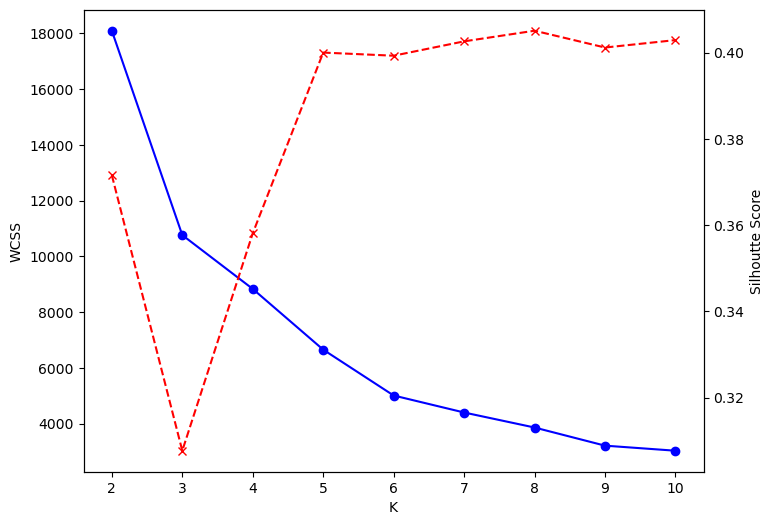

In [39]:
k_range =  range(2,11)
fig, ax1 = plt.subplots(figsize=(8,6))

ax1.plot(k_range, wcss[:len(k_range)] , marker="o", color="blue")
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2 = ax1.twinx()
ax2.plot(k_range, scores[:len(k_range)] , marker="x", color="red", linestyle="--")
ax2.set_ylabel("Silhoutte Score")


## Clustering

### 1. KMeans

In [40]:
kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(X_pca)

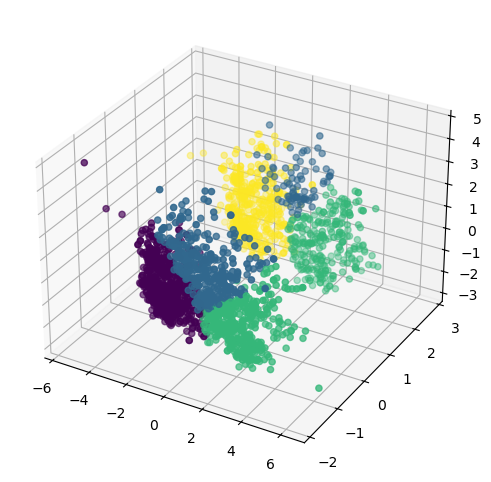

In [41]:
# plot 
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c = labels)

### 2. Agglomerative 

In [42]:
agg_clf = AgglomerativeClustering(n_clusters=4, linkage='ward')
labels_agg = agg_clf.fit_predict(X_pca)

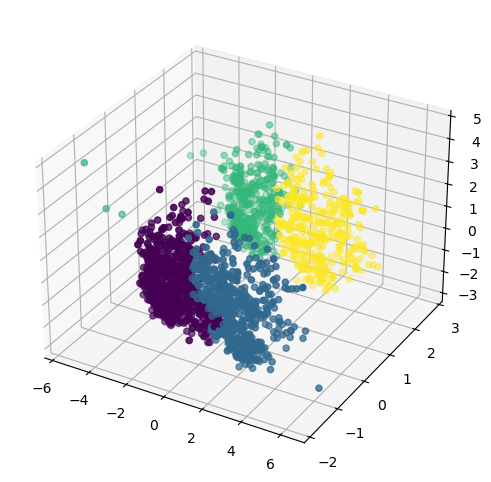

In [43]:
# plot 
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c = labels_agg)

In [44]:
# Based on the clustering visualization, Agglomerative Clustering provides better-defined clusters than K-Means.
# Therefore, in the next phase of this project, we will proceed with Agglomerative Clustering for further analysis.

## Characterization of Clustering

In [45]:
X['clusters'] = labels_agg

In [46]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_PostGraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner,clusters
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='clusters', ylabel='count'>

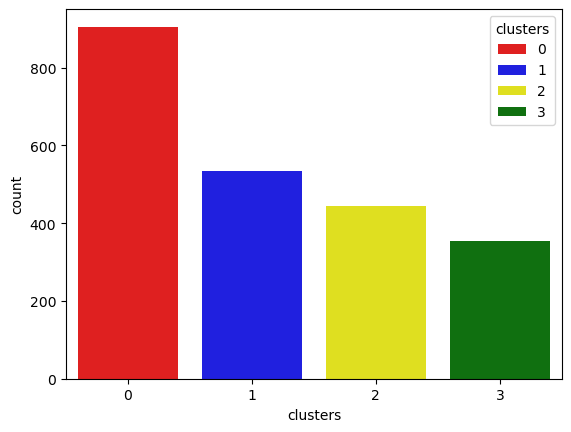

In [47]:
pal = ["red", "blue", "yellow", "green"]
sns.countplot(
    x=X['clusters'],
    palette=pal,
    hue = X['clusters']
    
)

In [48]:
# Income and spending pattern.

<Axes: xlabel='Total_Spending', ylabel='Income'>

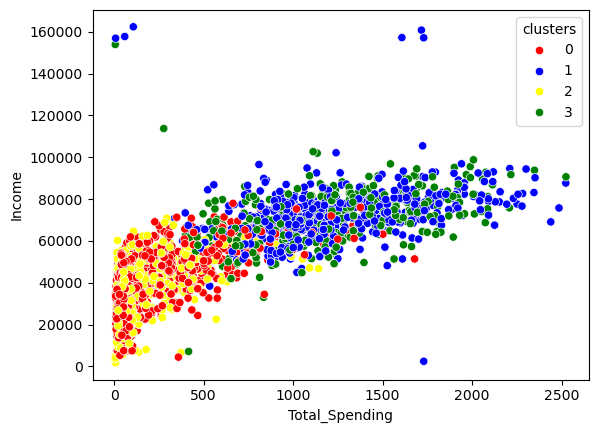

In [49]:
sns.scatterplot(
    x=X["Total_Spending"], 
    y=X["Income"],
    hue=X["clusters"],
    palette=pal
)

## Clusters Summary

In [50]:
cluster_summary = X.groupby("clusters").mean()
print(cluster_summary)

                Income    Recency  NumDealsPurchases  NumWebPurchases  \
clusters                                                                
0         39680.580110  48.914917           2.594475         3.153591   
1         72808.445693  49.202247           1.958801         5.687266   
2         36960.143018  48.319820           2.594595         2.713964   
3         70722.681303  50.504249           1.855524         5.790368   

          NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
clusters                                                                        
0                    0.969061           4.143646           6.307182  0.011050   
1                    5.498127           8.659176           3.580524  0.005618   
2                    0.837838           3.623874           6.659910  0.011261   
3                    5.014164           8.430595           3.728045  0.005666   

          Response        Age  Customer_Tenure_Days  Total_Spending  \
clu